# D2C Skincare: Sales, Customer & Product Analytics

## Project Overview

This project analyzes a D2C skincare e-commerce business to understand its sales performance, customer purchasing behavior, product profitability, marketing channels, payment patterns, and customer experience.

The analysis uses transactional data across customers, products, orders, order items, returns, and reviews. Python is used to prepare the data and perform business-focused exploratory and descriptive analysis, while SQL is used for advanced business analysis and RFM customer segmentation. The final insights are presented through a four-page Power BI dashboard.

## Business Objective

Analyze D2C skincare e-commerce data to evaluate sales performance, product profitability, customer purchasing behavior, sales channels, payment patterns, and customer experience, and identify actionable opportunities for business growth and improvement.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df1 = pd.read_csv(r"C:\Users\papus\OneDrive\Documents\D2C Project\Customers.csv")
df1.head(5)

,customer_id,customer_name,city,state,gender,age_group,signup_date,acquisition_channel
0,C0001,Ayaan Gupta,Hyderabad,Telangana,Female,35-44,08-09-2023,YouTube
1,C0002,Aarav Sharma,Gurugram,Haryana,Female,25-34,02-02-2023,Instagram
2,C0003,Kavya Kapoor,Noida,Uttar Pradesh,Other,18-24,23-07-2023,Google Search
3,C0004,Karan Mehta,Kochi,Kerala,Other,25-34,07-01-2023,YouTube
4,C0005,Vihaan Sharma,Lucknow,Uttar Pradesh,Male,18-24,11-12-2023,Google Search


In [3]:
df1.shape

(500, 8)

In [4]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   customer_id          500 non-null    object
 1   customer_name        500 non-null    object
 2   city                 500 non-null    object
 3   state                500 non-null    object
 4   gender               500 non-null    object
 5   age_group            500 non-null    object
 6   signup_date          500 non-null    object
 7   acquisition_channel  500 non-null    object
dtypes: object(8)
memory usage: 31.4+ KB


In [6]:
df1['signup_date'] = pd.to_datetime(df1['signup_date'], dayfirst=True)

In [7]:
df1.dtypes

customer_id                    object
customer_name                  object
city                           object
state                          object
gender                         object
age_group                      object
signup_date            datetime64[ns]
acquisition_channel            object
dtype: object

In [8]:
df1.isnull().sum()

customer_id            0
customer_name          0
city                   0
state                  0
gender                 0
age_group              0
signup_date            0
acquisition_channel    0
dtype: int64

In [9]:
df1.duplicated().sum()

np.int64(0)

In [10]:
df1.describe()

,signup_date
count,500
mean,2024-01-05 02:29:45.600000
min,2023-01-01 00:00:00
25%,2023-06-22 18:00:00
50%,2024-01-14 12:00:00
75%,2024-07-18 06:00:00
max,2024-11-30 00:00:00


In [11]:
df1.to_csv(
    r"C:\Users\papus\OneDrive\Documents\D2C Project\Customers_Cleaned.csv",
    index=False
)

In [13]:
df2=pd.read_csv(r"C:\Users\papus\OneDrive\Documents\D2C Project\Order_Items.csv")
df2.shape

(2042, 7)

In [14]:
df2.head(5)

,order_item_id,order_id,product_id,quantity,unit_price,discount_pct,item_total
0,OI000001,O00001,P023,1,499,15,424.15
1,OI000002,O00002,P020,1,349,0,349.00
2,OI000003,O00003,P001,2,549,10,988.20
3,OI000004,O00003,P002,1,599,20,479.20
4,OI000005,O00004,P009,2,349,5,663.10


In [15]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2042 entries, 0 to 2041
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   order_item_id  2042 non-null   object 
 1   order_id       2042 non-null   object 
 2   product_id     2042 non-null   object 
 3   quantity       2042 non-null   int64  
 4   unit_price     2042 non-null   int64  
 5   discount_pct   2042 non-null   int64  
 6   item_total     2042 non-null   float64
dtypes: float64(1), int64(3), object(3)
memory usage: 111.8+ KB


In [16]:
df2.isnull().sum()

order_item_id    0
order_id         0
product_id       0
quantity         0
unit_price       0
discount_pct     0
item_total       0
dtype: int64

In [17]:
df2.duplicated().sum()

np.int64(0)

In [18]:
df2.describe()

,quantity,unit_price,discount_pct,item_total
count,2042.000000,2042.000000,2042.000000,2042.000000
mean,1.262977,502.599412,9.603330,575.587659
std,0.522770,151.177064,7.219479,311.603978
min,1.000000,249.000000,0.000000,186.750000
25%,1.000000,399.000000,5.000000,359.100000
50%,1.000000,499.000000,10.000000,508.300000
75%,1.000000,599.000000,15.000000,664.050000
max,3.000000,799.000000,25.000000,2397.000000


In [19]:
df2.to_csv(
    r"C:\Users\papus\OneDrive\Documents\D2C Project\Order_items_Cleaned.csv",
    index=False
)

In [21]:
df3 = pd.read_csv(r"C:\Users\papus\OneDrive\Documents\D2C Project\Orders.csv")
df3.shape

(1250, 11)

In [22]:
df3.head()

,order_id,customer_id,order_date,order_status,payment_method,sales_channel,gross_amount,discount_amount,shipping_fee,final_amount,delivered_date
0,O00001,C0047,10-06-2024,Delivered,Debit Card,Mobile App,424.15,74.85,49,473.15,14-06-2024
1,O00002,C0016,18-02-2025,Delivered,Credit Card,Website,349.00,0.00,40,389.00,21-02-2025
2,O00003,C0191,03-12-2025,Delivered,Credit Card,Website,1467.40,229.60,0,1467.40,09-12-2025
3,O00004,C0087,10-08-2025,Delivered,Credit Card,Website,663.10,34.90,49,712.10,17-08-2025
4,O00005,C0211,17-07-2025,Delivered,UPI,Website,1511.35,134.65,0,1511.35,23-07-2025


In [23]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1250 entries, 0 to 1249
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         1250 non-null   object 
 1   customer_id      1250 non-null   object 
 2   order_date       1250 non-null   object 
 3   order_status     1250 non-null   object 
 4   payment_method   1250 non-null   object 
 5   sales_channel    1250 non-null   object 
 6   gross_amount     1250 non-null   float64
 7   discount_amount  1250 non-null   float64
 8   shipping_fee     1250 non-null   int64  
 9   final_amount     1250 non-null   float64
 10  delivered_date   1099 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 107.6+ KB


In [24]:
df3['delivered_date'] = pd.to_datetime(
    df3['delivered_date'],
    dayfirst=True
)

In [27]:
df3.dtypes

order_id                   object
customer_id                object
order_date                 object
order_status               object
payment_method             object
sales_channel              object
gross_amount              float64
discount_amount           float64
shipping_fee                int64
final_amount              float64
delivered_date     datetime64[ns]
dtype: object

In [28]:
df3.describe()

,gross_amount,discount_amount,shipping_fee,final_amount,delivered_date
count,1250.000000,1250.000000,1250.000000,1250.000000,1099
mean,940.280000,99.736800,21.565600,897.627720,2025-01-03 09:26:02.511374080
min,186.750000,0.000000,0.000000,0.000000,2024-01-06 00:00:00
25%,468.500000,34.900000,0.000000,444.100000,2024-08-03 12:00:00
50%,731.850000,74.850000,0.000000,713.125000,2024-12-15 00:00:00
75%,1225.637500,139.750000,49.000000,1187.025000,2025-07-06 00:00:00
max,3641.800000,584.050000,59.000000,3641.800000,2026-01-07 00:00:00
std,622.507995,92.479542,24.991578,637.805802,NaN


In [29]:
df3.isnull().sum()

order_id             0
customer_id          0
order_date           0
order_status         0
payment_method       0
sales_channel        0
gross_amount         0
discount_amount      0
shipping_fee         0
final_amount         0
delivered_date     151
dtype: int64

In [30]:
df3[df3['delivered_date'].isna()]['order_status'].value_counts()

order_status
Cancelled     86
In Transit    65
Name: count, dtype: int64

## Data Quality Note

The delivered_date column contains 151 missing values. These are valid business cases: 86 orders are Cancelled and 65 orders are In Transit, so no delivery date exists yet. Therefore, the missing values were retained as NaT rather than imputed.

In [31]:
df3.to_csv(
    r"C:\Users\papus\OneDrive\Documents\D2C Project\Orders_Cleaned.csv",
    index=False
)

In [32]:
df4 = pd.read_csv(r"C:\Users\papus\OneDrive\Documents\D2C Project\Products.csv")
df4.head()

,product_id,product_name,category,concern,skin_type,key_ingredient,size,mrp,cost_price,stock_qty,launch_date
0,P001,2% Salicylic Acid Face Serum,Serum,Acne Control,Oily / Acne-Prone,Salicylic Acid,30ml,549,247,220,15-01-2022
1,P002,10% Niacinamide Face Serum,Serum,Oil Control,Oily / Combination,Niacinamide,30ml,599,265,240,10-09-2021
2,P003,Vitamin C 10% Face Serum,Serum,Brightening,All Skin Types,Vitamin C,30ml,699,315,180,01-05-2022
3,P004,Alpha Arbutin 2% Serum,Serum,Pigmentation,All Skin Types,Alpha Arbutin,30ml,649,292,160,18-03-2022
4,P005,Retinol 0.3% Face Serum,Serum,Anti-Ageing,Normal / Dry,Retinol,30ml,699,318,140,11-08-2022


In [33]:
df4.shape

(28, 11)

In [34]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   product_id      28 non-null     object
 1   product_name    28 non-null     object
 2   category        28 non-null     object
 3   concern         28 non-null     object
 4   skin_type       28 non-null     object
 5   key_ingredient  28 non-null     object
 6   size            28 non-null     object
 7   mrp             28 non-null     int64 
 8   cost_price      28 non-null     int64 
 9   stock_qty       28 non-null     int64 
 10  launch_date     28 non-null     object
dtypes: int64(3), object(8)
memory usage: 2.5+ KB


In [35]:
df4['launch_date'] = pd.to_datetime(
    df4['launch_date'],
    dayfirst=True
)

In [36]:
df4.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28 entries, 0 to 27
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   product_id      28 non-null     object        
 1   product_name    28 non-null     object        
 2   category        28 non-null     object        
 3   concern         28 non-null     object        
 4   skin_type       28 non-null     object        
 5   key_ingredient  28 non-null     object        
 6   size            28 non-null     object        
 7   mrp             28 non-null     int64         
 8   cost_price      28 non-null     int64         
 9   stock_qty       28 non-null     int64         
 10  launch_date     28 non-null     datetime64[ns]
dtypes: datetime64[ns](1), int64(3), object(7)
memory usage: 2.5+ KB


In [37]:
df4.describe()

,mrp,cost_price,stock_qty,launch_date
count,28.000000,28.000000,28.000000,28
mean,491.857143,212.535714,210.892857,2022-10-31 23:08:34.285714176
min,249.000000,92.000000,110.000000,2021-08-16 00:00:00
25%,386.500000,154.750000,160.000000,2022-04-13 06:00:00
50%,449.000000,194.500000,210.000000,2022-11-29 12:00:00
75%,599.000000,265.250000,252.500000,2023-05-21 00:00:00
max,799.000000,372.000000,350.000000,2023-12-12 00:00:00
std,154.389050,77.155198,63.129109,NaN


In [38]:
df4.isnull().sum()

product_id        0
product_name      0
category          0
concern           0
skin_type         0
key_ingredient    0
size              0
mrp               0
cost_price        0
stock_qty         0
launch_date       0
dtype: int64

In [39]:
df4.duplicated().sum()

np.int64(0)

In [40]:
df4.to_csv(
    r"C:\Users\papus\OneDrive\Documents\D2C Project\Products_Cleaned.csv",
    index=False
)

In [41]:
df5=pd.read_csv(r"C:\Users\papus\OneDrive\Documents\D2C Project\Returns.csv")
df5.shape

(79, 6)

In [42]:
df5.head()

,return_id,order_id,product_id,return_date,return_reason,refund_status
0,R00001,O00011,P003,31-03-2024,Late delivery,Under Review
1,R00002,O00023,P007,17-05-2025,Skin irritation,Replacement Sent
2,R00003,O00032,P024,18-07-2024,Skin irritation,Refunded
3,R00004,O00062,P027,10-04-2024,Changed mind,Under Review
4,R00005,O00130,P017,26-08-2024,Skin irritation,Replacement Sent


In [43]:
df5.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 79 entries, 0 to 78
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   return_id      79 non-null     object
 1   order_id       79 non-null     object
 2   product_id     79 non-null     object
 3   return_date    79 non-null     object
 4   return_reason  79 non-null     object
 5   refund_status  79 non-null     object
dtypes: object(6)
memory usage: 3.8+ KB


In [44]:
df5['return_date'] = pd.to_datetime(
    df5['return_date'],
    dayfirst=True
)

In [47]:
df5.dtypes

return_id                object
order_id                 object
product_id               object
return_date      datetime64[ns]
return_reason            object
refund_status            object
dtype: object

In [48]:
df5.isnull().sum()

return_id        0
order_id         0
product_id       0
return_date      0
return_reason    0
refund_status    0
dtype: int64

In [49]:
df5.duplicated().sum()

np.int64(0)

In [50]:
df5.to_csv(
    r"C:\Users\papus\OneDrive\Documents\D2C Project\Returns_Cleaned.csv",
    index=False
)

In [51]:
df6 = pd.read_csv(r"C:\Users\papus\OneDrive\Documents\D2C Project\Reviews.csv")
df6.head()

,review_id,customer_id,product_id,order_id,rating,review_date
0,RV00001,C0047,P023,O00001,4,19-06-2024
1,RV00002,C0191,P001,O00003,5,08-12-2025
2,RV00003,C0087,P009,O00004,5,29-08-2025
3,RV00004,C0289,P007,O00009,1,17-06-2024
4,RV00005,C0476,P016,O00012,3,04-10-2025


In [52]:
df6.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 494 entries, 0 to 493
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    494 non-null    object
 1   customer_id  494 non-null    object
 2   product_id   494 non-null    object
 3   order_id     494 non-null    object
 4   rating       494 non-null    int64 
 5   review_date  494 non-null    object
dtypes: int64(1), object(5)
memory usage: 23.3+ KB


In [53]:
df6['review_date'] = pd.to_datetime(
    df6['review_date'],
    dayfirst=True
)

In [55]:
df6.dtypes

review_id              object
customer_id            object
product_id             object
order_id               object
rating                  int64
review_date    datetime64[ns]
dtype: object

In [56]:
df6.to_csv(
    r"C:\Users\papus\OneDrive\Documents\D2C Project\Reviews_Cleaned.csv",
    index=False
)

In [57]:
customers = pd.read_csv(
    r"C:\Users\papus\OneDrive\Documents\D2C Project\Customers_Cleaned.csv",
    parse_dates=['signup_date']
)

products = pd.read_csv(
    r"C:\Users\papus\OneDrive\Documents\D2C Project\Products_Cleaned.csv",
    parse_dates=['launch_date']
)

orders = pd.read_csv(
    r"C:\Users\papus\OneDrive\Documents\D2C Project\Orders_Cleaned.csv",
    parse_dates=['order_date', 'delivered_date']
)

order_items = pd.read_csv(
    r"C:\Users\papus\OneDrive\Documents\D2C Project\Order_items_Cleaned.csv"
)

returns = pd.read_csv(
    r"C:\Users\papus\OneDrive\Documents\D2C Project\Returns_Cleaned.csv",
    parse_dates=['return_date']
)

reviews = pd.read_csv(
    r"C:\Users\papus\OneDrive\Documents\D2C Project\Reviews_Cleaned.csv",
    parse_dates=['review_date']
)

## Buisness KPI 

In [58]:
# Filter delivered orders
delivered_orders = orders[
    orders['order_status'] == 'Delivered'
].copy()

# Business KPIs
total_revenue = delivered_orders['final_amount'].sum()
total_orders = delivered_orders['order_id'].nunique()
total_customers = delivered_orders['customer_id'].nunique()

aov = total_revenue / total_orders

# Gross Profit
delivered_items = order_items[
    order_items['order_id'].isin(delivered_orders['order_id'])
].merge(
    products[['product_id', 'cost_price']],
    on='product_id',
    how='left'
)

delivered_items['cost'] = (
    delivered_items['quantity'] * delivered_items['cost_price']
)

cogs = delivered_items['cost'].sum()
gross_profit = delivered_items['item_total'].sum() - cogs
gross_margin = (gross_profit / delivered_items['item_total'].sum()) * 100

# Return Rate
total_returns = returns[
    returns['order_id'].isin(delivered_orders['order_id'])
]['order_id'].nunique()

return_rate = (total_returns / total_orders) * 100

# Display KPI values
kpis = pd.DataFrame({
    'KPI': [
        'Total Revenue',
        'Total Orders',
        'Total Customers',
        'Average Order Value',
        'Gross Profit',
        'Gross Margin %',
        'Return Rate %'
    ],
    'Value': [
        f'₹{total_revenue:,.2f}',
        f'{total_orders:,}',
        f'{total_customers:,}',
        f'₹{aov:,.2f}',
        f'₹{gross_profit:,.2f}',
        f'{gross_margin:.2f}%',
        f'{return_rate:.2f}%'
    ]
})

kpis

,KPI,Value
0,Total Revenue,"₹981,950.65"
1,Total Orders,"1,020"
2,Total Customers,438
3,Average Order Value,₹962.70
4,Gross Profit,"₹499,123.65"
5,Gross Margin %,52.08%
6,Return Rate %,0.00%


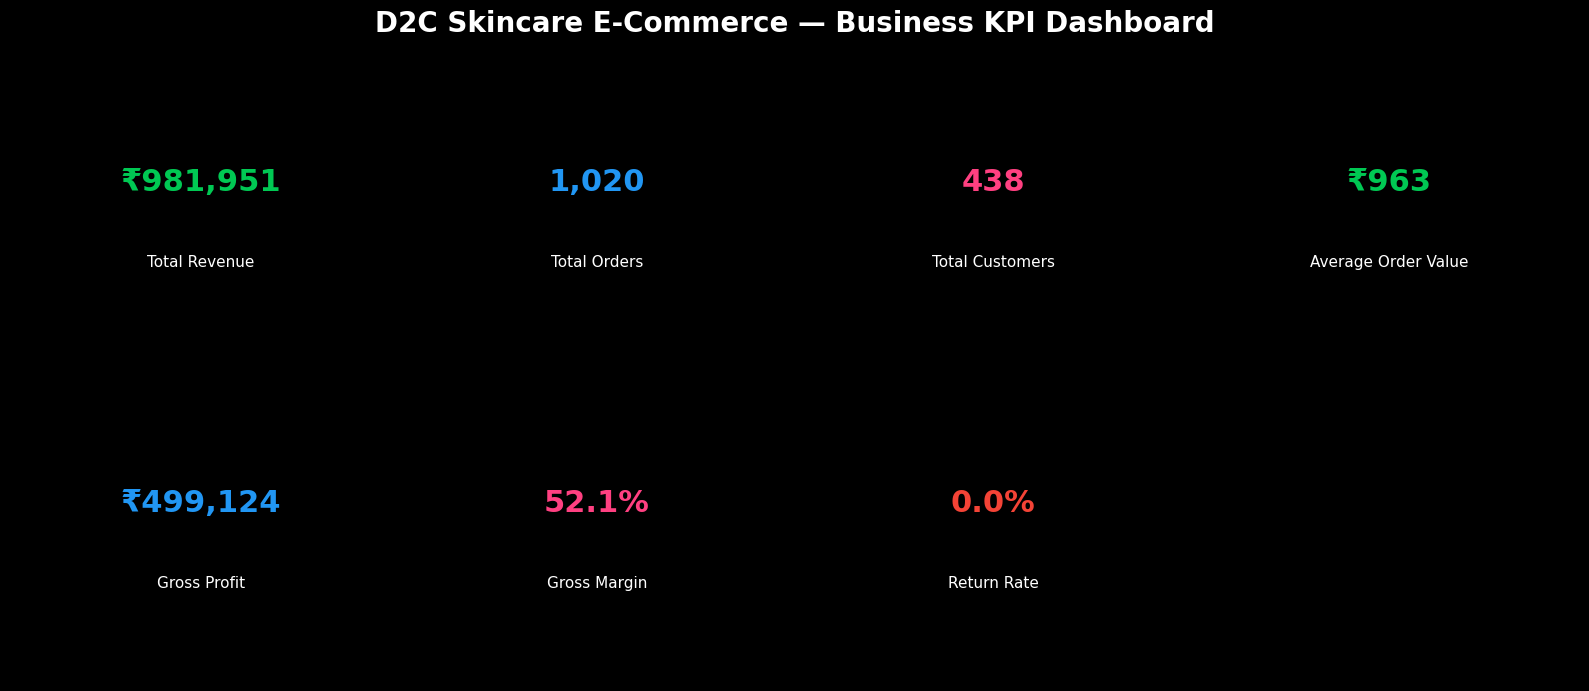

In [59]:
import matplotlib.pyplot as plt

# KPI values
kpi_data = [
    ("Total Revenue", f"₹{total_revenue:,.0f}", "#00C853"),
    ("Total Orders", f"{total_orders:,}", "#2196F3"),
    ("Total Customers", f"{total_customers:,}", "#FF4081"),
    ("Average Order Value", f"₹{aov:,.0f}", "#00C853"),
    ("Gross Profit", f"₹{gross_profit:,.0f}", "#2196F3"),
    ("Gross Margin", f"{gross_margin:.1f}%", "#FF4081"),
    ("Return Rate", f"{return_rate:.1f}%", "#F44336")
]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
fig.patch.set_facecolor("#000000")

axes = axes.flatten()

for i, (title, value, color) in enumerate(kpi_data):
    axes[i].set_facecolor("#000000")
    
    # KPI value
    axes[i].text(
        0.5, 0.58, value,
        ha="center",
        va="center",
        fontsize=22,
        fontweight="bold",
        color=color
    )
    
    # KPI title
    axes[i].text(
        0.5, 0.32, title,
        ha="center",
        va="center",
        fontsize=11,
        color="white"
    )
    
    axes[i].set_xticks([])
    axes[i].set_yticks([])
    
    for spine in axes[i].spines.values():
        spine.set_visible(False)

# Hide unused 8th card
axes[7].axis("off")

fig.suptitle(
    "D2C Skincare E-Commerce — Business KPI Dashboard",
    fontsize=20,
    fontweight="bold",
    color="white",
    y=0.98
)

plt.tight_layout()
plt.show()

## Revenue Analysis

### 1. Monthly Revenue Trend

In [61]:
orders['order_date'] = pd.to_datetime(
    orders['order_date'],
    dayfirst=True
)

In [62]:
delivered_orders = orders[
    orders['order_status'] == 'Delivered'
].copy()

In [63]:
monthly_revenue = (
    delivered_orders
    .assign(month=delivered_orders['order_date'].dt.to_period('M'))
    .groupby('month')['final_amount']
    .sum()
    .reset_index()
)

monthly_revenue['month'] = monthly_revenue['month'].astype(str)

monthly_revenue

,month,final_amount
0,2024-01,27410.05
1,2024-02,28167.60
2,2024-03,38019.55
3,2024-04,39619.40
4,2024-05,38095.40
5,2024-06,38241.30
6,2024-07,30433.85
7,2024-08,75061.15
8,2024-09,32270.25
9,2024-10,75502.25


## Monthly Revenue Visualization

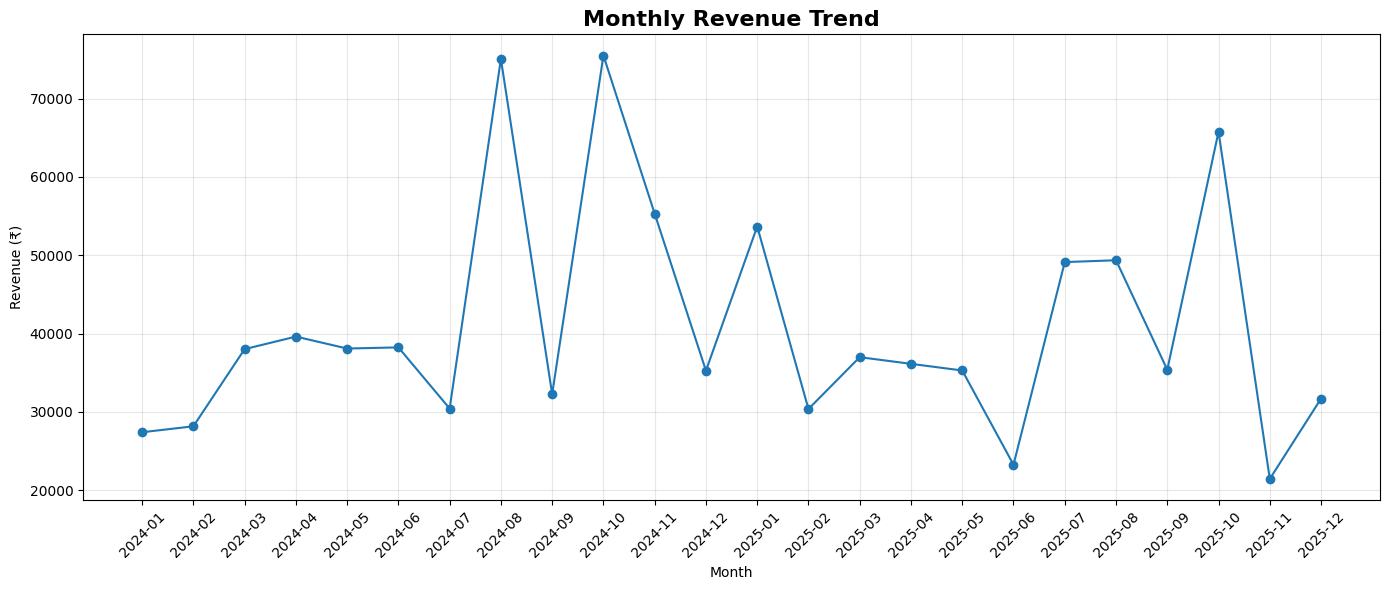

In [64]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_revenue['month'],
    monthly_revenue['final_amount'],
    marker='o'
)

plt.title('Monthly Revenue Trend', fontsize=16, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Revenue by Year

In [65]:
yearly_revenue = (
    delivered_orders
    .assign(year=delivered_orders['order_date'].dt.year)
    .groupby('year')['final_amount']
    .sum()
    .reset_index()
)

yearly_revenue

,year,final_amount
0,2024,513397.55
1,2025,468553.10


## Revenue Growth — YoY

In [66]:
yearly_revenue['YoY Growth %'] = (
    yearly_revenue['final_amount']
    .pct_change() * 100
)

yearly_revenue

,year,final_amount,YoY Growth %
0,2024,513397.55,NaN
1,2025,468553.10,-8.734839


## Revenue by Order Status

In [67]:
revenue_by_status = (
    orders
    .groupby('order_status')['final_amount']
    .sum()
    .reset_index()
    .sort_values('final_amount', ascending=False)
)

revenue_by_status

,order_status,final_amount
1,Delivered,981950.65
3,Returned,78945.70
2,In Transit,61138.30
0,Cancelled,0.00


# Sales Channel Analysis

## Revenue by Sales Channel

In [68]:
channel_revenue = (
    delivered_orders
    .groupby('sales_channel')['final_amount']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

channel_revenue

,sales_channel,final_amount
0,Website,548168.95
1,Mobile App,345441.70
2,Marketplace,88340.00


## Revenue Contribution %

In [69]:
channel_revenue['revenue_share_%'] = (
    channel_revenue['final_amount']
    / channel_revenue['final_amount'].sum()
    * 100
)

channel_revenue

,sales_channel,final_amount,revenue_share_%
0,Website,548168.95,55.824491
1,Mobile App,345441.70,35.179130
2,Marketplace,88340.00,8.996379


## Orders by Sales Channel

In [70]:
channel_orders = (
    delivered_orders
    .groupby('sales_channel')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name='orders')
)

channel_orders

,sales_channel,orders
0,Website,577
1,Mobile App,353
2,Marketplace,90


## Average Order Value by Channel

In [71]:
channel_aov = (
    delivered_orders
    .groupby('sales_channel')
    .agg(
        orders=('order_id', 'nunique'),
        revenue=('final_amount', 'sum')
    )
    .reset_index()
)

channel_aov['AOV'] = (
    channel_aov['revenue'] / channel_aov['orders']
)

channel_aov.sort_values('revenue', ascending=False)

,sales_channel,orders,revenue,AOV
2,Website,577,548168.95,950.032842
1,Mobile App,353,345441.70,978.588385
0,Marketplace,90,88340.00,981.555556


## Channel Performance Chart

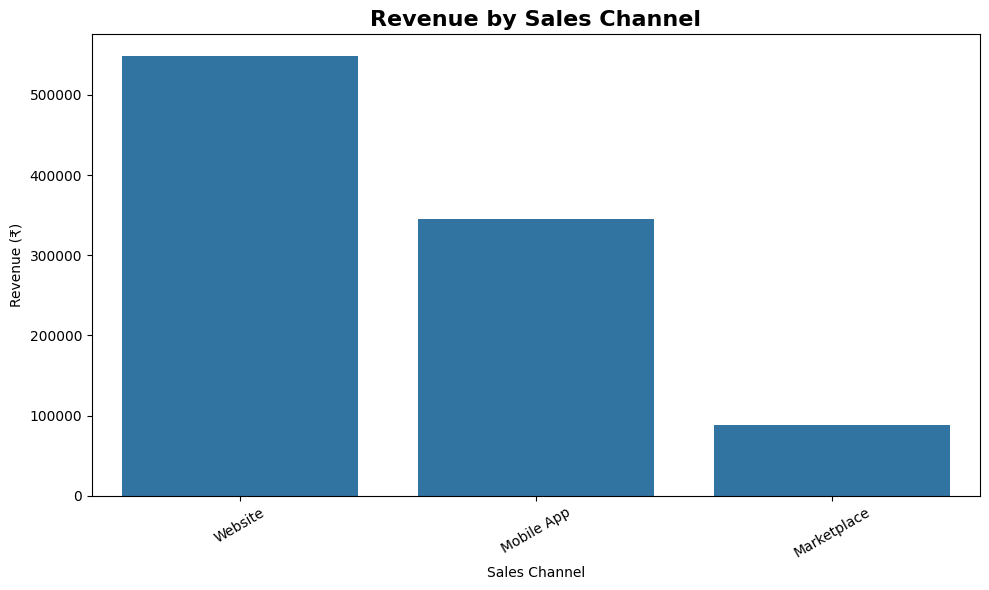

In [72]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=channel_revenue,
    x='sales_channel',
    y='final_amount'
)

plt.title('Revenue by Sales Channel', fontsize=16, fontweight='bold')
plt.xlabel('Sales Channel')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## Payment Method Analysis

### Revenue by Payment Method

In [73]:
payment_revenue = (
    delivered_orders
    .groupby('payment_method')['final_amount']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

payment_revenue

,payment_method,final_amount
0,UPI,422503.20
1,Credit Card,203525.80
2,Debit Card,146814.70
3,Net Banking,110324.55
4,COD,98782.40


### Revenue Contribution %

In [74]:
payment_revenue['revenue_share_%'] = (
    payment_revenue['final_amount']
    / payment_revenue['final_amount'].sum()
    * 100
)

payment_revenue

,payment_method,final_amount,revenue_share_%
0,UPI,422503.20,43.026928
1,Credit Card,203525.80,20.726683
2,Debit Card,146814.70,14.951332
3,Net Banking,110324.55,11.235244
4,COD,98782.40,10.059813


### Orders by Payment Method

In [75]:
payment_orders = (
    delivered_orders
    .groupby('payment_method')['order_id']
    .nunique()
    .sort_values(ascending=False)
    .reset_index(name='orders')
)

payment_orders

,payment_method,orders
0,UPI,419
1,Credit Card,217
2,Debit Card,168
3,Net Banking,113
4,COD,103


### AOV by Payment Method

In [76]:
payment_aov = (
    delivered_orders
    .groupby('payment_method')
    .agg(
        orders=('order_id', 'nunique'),
        revenue=('final_amount', 'sum')
    )
    .reset_index()
)

payment_aov['AOV'] = (
    payment_aov['revenue'] / payment_aov['orders']
)

payment_aov.sort_values('revenue', ascending=False)

,payment_method,orders,revenue,AOV
4,UPI,419,422503.20,1008.360859
1,Credit Card,217,203525.80,937.906912
2,Debit Card,168,146814.70,873.897024
3,Net Banking,113,110324.55,976.323451
0,COD,103,98782.40,959.052427


### Payment Method Revenue Chart

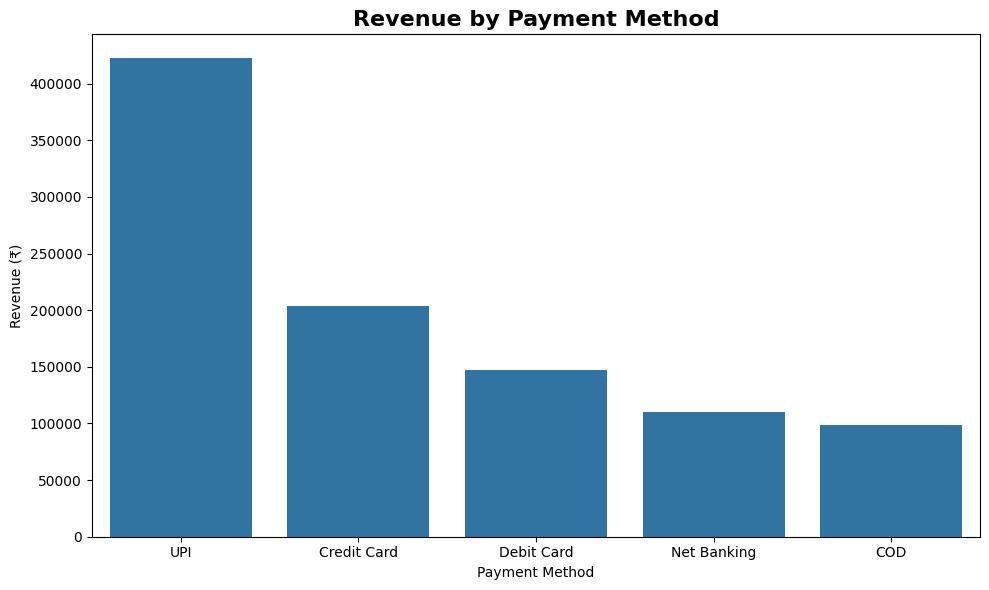

In [77]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=payment_revenue,
    x='payment_method',
    y='final_amount'
)

plt.title('Revenue by Payment Method', fontsize=16, fontweight='bold')
plt.xlabel('Payment Method')
plt.ylabel('Revenue (₹)')

plt.tight_layout()
plt.show()

# Customer Demographics & Acquisition Analysis

### Customer Distribution by Gender

In [78]:
gender_analysis = (
    customers['gender']
    .value_counts()
    .reset_index()
)

gender_analysis.columns = ['gender', 'customers']
gender_analysis['customer_share_%'] = (
    gender_analysis['customers']
    / gender_analysis['customers'].sum() * 100
)

gender_analysis

,gender,customers,customer_share_%
0,Female,181,36.2
1,Male,169,33.8
2,Other,150,30.0


### Customer Distribution by Age Group

In [79]:
age_analysis = (
    customers['age_group']
    .value_counts()
    .reset_index()
)

age_analysis.columns = ['age_group', 'customers']
age_analysis['customer_share_%'] = (
    age_analysis['customers']
    / age_analysis['customers'].sum() * 100
)

age_analysis

,age_group,customers,customer_share_%
0,25-34,244,48.8
1,18-24,120,24.0
2,35-44,86,17.2
3,45+,50,10.0


### Customer Distribution by State

In [80]:
state_analysis = (
    customers['state']
    .value_counts()
    .reset_index()
)

state_analysis.columns = ['state', 'customers']

state_analysis

,state,customers
0,Maharashtra,78
1,Gujarat,71
2,Madhya Pradesh,61
3,Uttar Pradesh,56
4,Tamil Nadu,36
5,Kerala,31
6,Haryana,30
7,Karnataka,28
8,Delhi,25
9,Rajasthan,25


### Acquisition Channel Performance

In [81]:
acquisition_analysis = (
    delivered_orders
    .merge(
        customers[['customer_id', 'acquisition_channel']],
        on='customer_id',
        how='left'
    )
    .groupby('acquisition_channel')
    .agg(
        customers=('customer_id', 'nunique'),
        orders=('order_id', 'nunique'),
        revenue=('final_amount', 'sum')
    )
    .reset_index()
)

acquisition_analysis['revenue_share_%'] = (
    acquisition_analysis['revenue']
    / acquisition_analysis['revenue'].sum() * 100
)

acquisition_analysis['AOV'] = (
    acquisition_analysis['revenue']
    / acquisition_analysis['orders']
)

acquisition_analysis.sort_values(
    'revenue',
    ascending=False
)

,acquisition_channel,customers,orders,revenue,revenue_share_%,AOV
0,Google Search,131,301,281495.25,28.666945,935.200166
1,Instagram,123,282,272874.80,27.789054,967.641135
4,YouTube,65,147,142784.80,14.540934,971.325170
2,Referral,56,148,142400.25,14.501773,962.163851
3,Website Direct,63,142,142395.55,14.501294,1002.785563


### Acquisition Channel — Revenue Chart

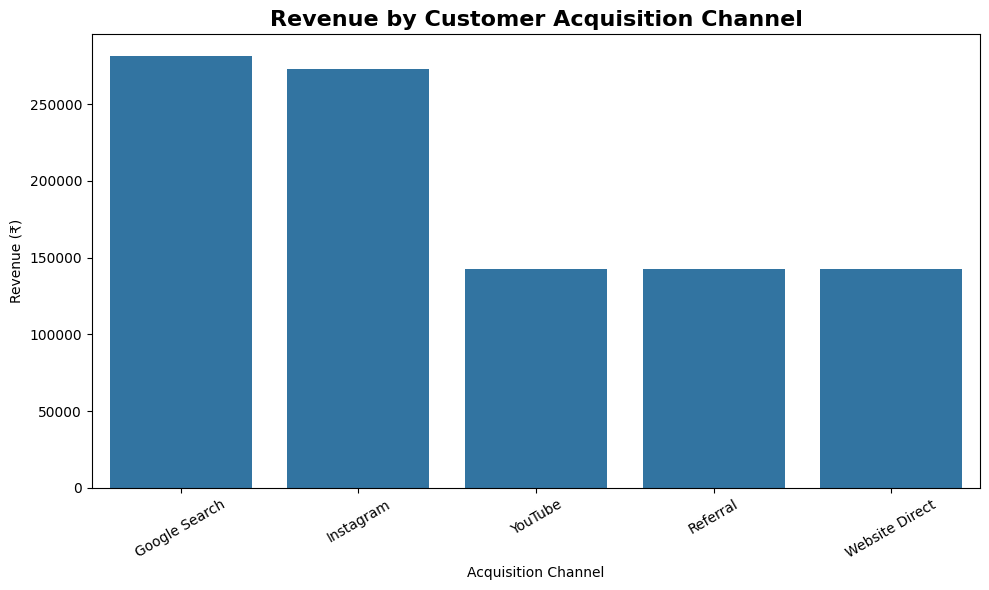

In [82]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=acquisition_analysis.sort_values('revenue', ascending=False),
    x='acquisition_channel',
    y='revenue'
)

plt.title(
    'Revenue by Customer Acquisition Channel',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Acquisition Channel')
plt.ylabel('Revenue (₹)')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

# Product & Profitability Analysis

## Creating Product Performance Dataset

In [83]:
product_analysis = (
    order_items
    .merge(
        products[['product_id', 'product_name', 'category', 'mrp', 'cost_price']],
        on='product_id',
        how='left'
    )
    .merge(
        delivered_orders[['order_id']],
        on='order_id',
        how='inner'
    )
)

product_analysis['cogs'] = (
    product_analysis['quantity'] * product_analysis['cost_price']
)

product_analysis['gross_profit'] = (
    product_analysis['item_total'] - product_analysis['cogs']
)

## Product Performance

In [84]:
product_performance = (
    product_analysis
    .groupby(['product_id', 'product_name', 'category'])
    .agg(
        units_sold=('quantity', 'sum'),
        revenue=('item_total', 'sum'),
        gross_profit=('gross_profit', 'sum'),
        orders=('order_id', 'nunique')
    )
    .reset_index()
)

product_performance['gross_margin_%'] = (
    product_performance['gross_profit']
    / product_performance['revenue'] * 100
)

product_performance.sort_values(
    'revenue',
    ascending=False
)

,product_id,product_name,category,units_sold,revenue,gross_profit,orders,gross_margin_%
3,P004,Alpha Arbutin 2% Serum,Serum,130,76549.55,38589.55,103,50.411204
1,P002,10% Niacinamide Face Serum,Serum,114,61427.45,31217.45,86,50.820032
5,P006,Hyaluronic Acid 2% Serum,Serum,108,58432.45,30568.45,79,52.314168
2,P003,Vitamin C 10% Face Serum,Serum,88,55570.50,27850.50,66,50.117418
13,P014,SPF 60 PA++++ Sunscreen,Sunscreen,119,53592.60,28483.60,86,53.148382
23,P024,Hair Growth Actives Serum,Hair Care,73,52973.70,25817.70,54,48.736826
7,P008,Granactive Retinoid 2% Serum,Serum,66,47340.75,23712.75,54,50.089511
4,P005,Retinol 0.3% Face Serum,Serum,71,44631.15,22053.15,52,49.412014
6,P007,AHA BHA 10% Exfoliating Serum,Serum,68,43407.90,21511.90,58,49.557569
0,P001,2% Salicylic Acid Face Serum,Serum,87,43343.55,21854.55,69,50.421689


## Category Profitability

In [85]:
category_profitability = (
    product_performance
    .groupby('category')
    .agg(
        units_sold=('units_sold', 'sum'),
        revenue=('revenue', 'sum'),
        gross_profit=('gross_profit', 'sum')
    )
    .reset_index()
)

category_profitability['gross_margin_%'] = (
    category_profitability['gross_profit']
    / category_profitability['revenue'] * 100
)

category_profitability.sort_values(
    'gross_profit',
    ascending=False
)

,category,units_sold,revenue,gross_profit,gross_margin_%
6,Serum,732,430703.30,217358.30,50.465901
5,Moisturizer,359,126460.75,67880.75,53.677327
7,Sunscreen,273,112636.55,59663.55,52.969973
3,Hair Care,183,109034.60,54283.60,49.785664
1,Cleanser,236,68929.40,38561.40,55.943328
0,Body Care,104,40119.55,22019.55,54.884838
2,Eye Care,89,35223.90,19359.90,54.962398
8,Toner,63,21122.95,11636.95,55.091500
4,Lip Care,63,14155.65,8359.65,59.055218


## Top 10 Products by Revenue

In [86]:
top_products = product_performance.nlargest(
    10, 'revenue'
)

top_products[['product_name', 'category', 'revenue', 'gross_profit']]

,product_name,category,revenue,gross_profit
3,Alpha Arbutin 2% Serum,Serum,76549.55,38589.55
1,10% Niacinamide Face Serum,Serum,61427.45,31217.45
5,Hyaluronic Acid 2% Serum,Serum,58432.45,30568.45
2,Vitamin C 10% Face Serum,Serum,55570.50,27850.50
13,SPF 60 PA++++ Sunscreen,Sunscreen,53592.60,28483.60
23,Hair Growth Actives Serum,Hair Care,52973.70,25817.70
7,Granactive Retinoid 2% Serum,Serum,47340.75,23712.75
4,Retinol 0.3% Face Serum,Serum,44631.15,22053.15
6,AHA BHA 10% Exfoliating Serum,Serum,43407.90,21511.90
0,2% Salicylic Acid Face Serum,Serum,43343.55,21854.55


## Revenue by Category

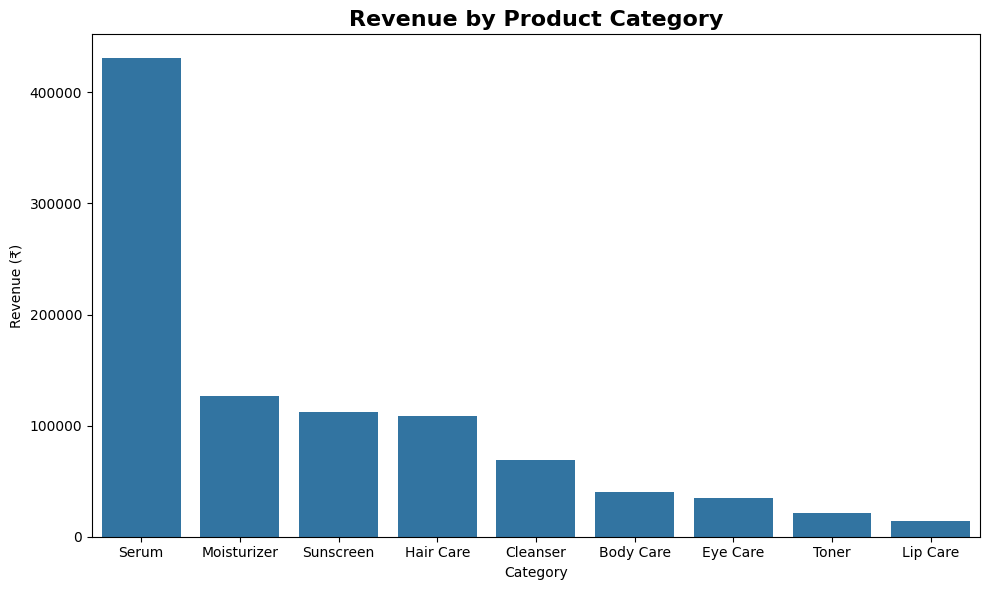

In [87]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_profitability.sort_values(
        'revenue',
        ascending=False
    ),
    x='category',
    y='revenue'
)

plt.title(
    'Revenue by Product Category',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Category')
plt.ylabel('Revenue (₹)')

plt.tight_layout()
plt.show()

## Gross Margin by Category

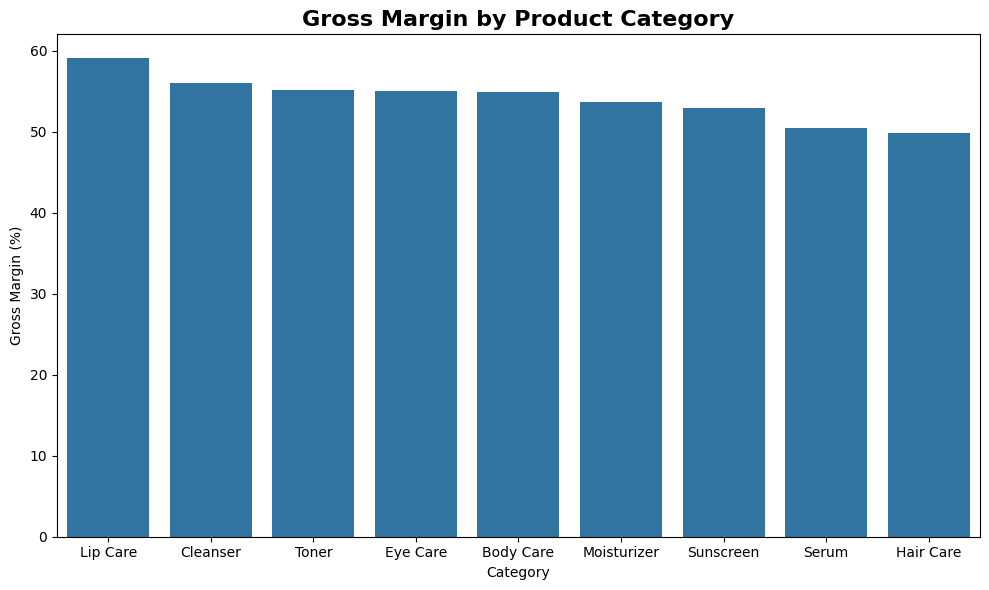

In [88]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_profitability.sort_values(
        'gross_margin_%',
        ascending=False
    ),
    x='category',
    y='gross_margin_%'
)

plt.title(
    'Gross Margin by Product Category',
    fontsize=16,
    fontweight='bold'
)

plt.xlabel('Category')
plt.ylabel('Gross Margin (%)')

plt.tight_layout()
plt.show()